# Diverted Hyrophone Metadata/Data Review

In [16]:
import obspy as obs
import numpy as np
import fsspec
import matplotlib.pyplot as plt

In [3]:
def get_mseed_urls(day_str, refdes, addendum=False):

    base_url = "https://rawdata.oceanobservatories.org/files"
    if addendum:
        mainurl = f"{base_url}/{refdes[0:8]}/{refdes[9:14]}/{refdes[15:27]}/{day_str}/addendum"
    else:
        mainurl = f"{base_url}/{refdes[0:8]}/{refdes[9:14]}/{refdes[15:27]}/{day_str}/"
    FS = fsspec.filesystem("http")
    print(mainurl)

    try:
        data_url_list = sorted(
            f["name"]
            for f in FS.ls(mainurl)
            if f["type"] == "file" and f["name"].endswith(".mseed")
        )
    except Exception as e:
        print("Client response: ", e)
        return None

    if not data_url_list:
        print("No Data Available for Specified Time")
        return None

    return data_url_list

In [4]:
day_str = "2026/01/06"
refdes = "RS01SLBS-LJ01A-HYDBBA102"

In [5]:
url_list = get_mseed_urls(day_str, refdes, addendum=True)

https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum


In [6]:
st_list = []
for url in url_list[:60]: # first 20 files in addendum directory
    st = obs.read(url)
    print(url)
    st_list.append(st)

https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:00:00.000000Z.mseed
https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:05:00.000000Z.mseed
https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:10:00.000000Z.mseed
https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:15:00.000000Z.mseed
https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:20:00.000000Z.mseed
https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:25:00.000000Z.mseed
https://rawdata.oceanobservatories.org/files/RS01SLBS/LJ01A/HYDBBA102/2026/01/06/addendum/./OO-HYVM1--YDH-2026-01-06T00:30:00.000000Z.mseed
https://rawdata.ocea

In [7]:
# print stream metadata for the first 30 files in the addendum
for st in st_list:
    print(st)

3 Trace(s) in Stream:
OO.HYVM1..YDH | 2026-01-06T00:00:00.000000Z - 2026-01-06T00:02:51.339984Z | 64000.0 Hz, 10965760 samples
OO.HYVM1..YDH | 2026-01-06T00:02:51.330000Z - 2026-01-06T00:02:51.579984Z | 64000.0 Hz, 16000 samples
OO.HYVM1..YDH | 2026-01-06T00:02:51.590000Z - 2026-01-06T00:04:50.089984Z | 64000.0 Hz, 7584000 samples
1 Trace(s) in Stream:
OO.HYVM1..YDH | 2026-01-06T00:09:50.090000Z - 2026-01-06T00:09:59.999984Z | 64000.0 Hz, 634240 samples
1 Trace(s) in Stream:
OO.HYVM1..YDH | 2026-01-06T00:10:00.000000Z - 2026-01-06T00:14:50.089984Z | 64000.0 Hz, 18565760 samples
1 Trace(s) in Stream:
OO.HYVM1..YDH | 2026-01-06T00:19:50.090000Z - 2026-01-06T00:19:59.999984Z | 64000.0 Hz, 634240 samples
1 Trace(s) in Stream:
OO.HYVM1..YDH | 2026-01-06T00:24:50.090000Z - 2026-01-06T00:24:59.999984Z | 64000.0 Hz, 634240 samples
1 Trace(s) in Stream:
OO.HYVM1..YDH | 2026-01-06T00:25:00.000000Z - 2026-01-06T00:29:50.089984Z | 64000.0 Hz, 18565760 samples
1 Trace(s) in Stream:
OO.HYVM1..YDH | 

In [8]:
# print stream metadata for the first 30 files in the addendum
for st in st_list:
    for tr in st:
        print(tr.stats)
        print("------------------------------------------------------------------------------------")

         network: OO
         station: HYVM1
        location: 
         channel: YDH
       starttime: 2026-01-06T00:00:00.000000Z
         endtime: 2026-01-06T00:02:51.339984Z
   sampling_rate: 64000.0
           delta: 1.5625e-05
            npts: 10965760
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 4113, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 4096, 'filesize': 28520448})
------------------------------------------------------------------------------------
         network: OO
         station: HYVM1
        location: 
         channel: YDH
       starttime: 2026-01-06T00:02:51.330000Z
         endtime: 2026-01-06T00:02:51.579984Z
   sampling_rate: 64000.0
           delta: 1.5625e-05
            npts: 16000
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 6, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 4096, 'files

In [9]:
merged_stream = sum(st_list, obs.Stream())

In [10]:
merged_stream

6676 Trace(s) in Stream:

OO.HYVM1..YDH | 2026-01-06T00:00:00.000000Z - 2026-01-06T00:02:51.339984Z | 64000.0 Hz, 10965760 samples
...
(6674 other traces)
...
OO.HYVM1..YDH | 2026-01-06T04:59:59.840000Z - 2026-01-06T04:59:59.999984Z | 64000.0 Hz, 10240 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

<Figure size 2500x900 with 0 Axes>

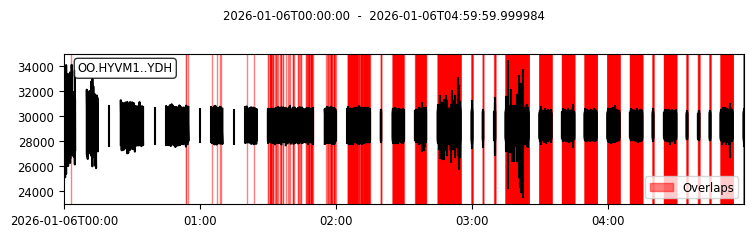

In [19]:
plt.figure(figsize=(25, 9)) #

_ = merged_stream.plot()